In [ ]:
# Some basics:
import os
import pandas as pd
from tqdm import tqdm

# Declare Filepaths
segmentation_categories_path = r"~\Lib\category_mapping.xlsx"
frames_path = r"~\Data\Semantic_01_Segmentation\Robust_batch"

# Extract the relevant index and semantic category name from the file
segmentation_categories = pd.read_excel(segmentation_categories_path, index_col=0)
category_mapping = {
    idx: (category, designation)
    for idx, category, designation in zip(
        segmentation_categories['Idx'],
        segmentation_categories['Category'],
        segmentation_categories['Designation']
    )
}


# Iterate through each frames folder
for frames_folder in os.listdir(frames_path):
    # Construct the full path to the frames folder
    frames_folder_path = os.path.join(frames_path, frames_folder)

    # Check if the item in the frames folder is a directory
    if os.path.isdir(frames_folder_path):
        # Create an empty DataFrame to store the counts per frame
        frame_counts = pd.DataFrame(columns=['Frame', 'personal', 'spatial', 'object', 'other'])

        # Get the list of frames files in the folder
        frames_files = [file for file in os.listdir(frames_folder_path) if file.endswith('.csv')]

        # Initialize the progress bar
        progress_bar = tqdm(frames_files, desc=f"Processing {frames_folder}", unit="file")

        # Iterate through the frames files
        for frames_file in frames_files:
            # Construct the full path to the frames file
            frames_file_path = os.path.join(frames_folder_path, frames_file)

            # Read the frames file, ignoring the first column as index
            frames_data = pd.read_csv(frames_file_path, delimiter=';', header=None, index_col=0)

            file_counts = {
            1: 0,  # Personal
            2: 0,  # Spatial
            3: 0,  # Object
            4: 0   # Other
            }

            # Iterate through the rows in the frames file
            for _, row in frames_data.iterrows():
                for number in row:
                    # Check if the number is NaN
                    if pd.isnull(number):
                        continue
                    number = int(number)

                    # Check if the number exists in the category mapping
                    if number in category_mapping:
                        _, designation = category_mapping[number]
                        #print(designation)

                        # Update the count for the corresponding designation
                        if designation in file_counts:
                            file_counts[designation] += 1
                            #print(file_counts)

            # Extract the frame number from the frames file name
            frame_number = frames_file[:-4]  # Remove the file extension

            # Create a DataFrame for the current frames file
            file_frame_counts = pd.DataFrame(
                {'Frame': [frame_number],
                 'personal': [file_counts[1]],
                 'spatial': [file_counts[2]],
                 'object': [file_counts[3]],
                 'other': [file_counts[4]]}
            )

            # Append the current frames file DataFrame to the list
            frame_counts_list.append(file_frame_counts)

        # Concatenate the frame_counts_list into a single DataFrame
        frame_counts = pd.concat(frame_counts_list, ignore_index=True)


        # Save the frame_counts DataFrame to a CSV file
        output_file = os.path.join(frames_folder_path, f"{frames_folder}_frame_counts.csv")
        frame_counts.to_csv(output_file, index=False)

        # Print the counts for each designation per film (frames folder)
        print(f"Designation counts for {frames_folder}:")
        print(frame_counts[['personal', 'spatial', 'object', 'other']].sum())
        print()


In [ ]:
# Some basics:
import os
import pandas as pd
from tqdm import tqdm

# Declare Filepaths
segmentation_categories_path = r"~\Lib\category_mapping.xlsx"
frames_path = r"~\Data\Semantic_01_Segmentation\Robust_batch"

# Extract the relevant index and semantic category name from the file
segmentation_categories = pd.read_excel(segmentation_categories_path, index_col=0)
category_mapping = {
    idx: (category, designation)
    for idx, category, designation in zip(
        segmentation_categories['Idx'],
        segmentation_categories['Category'],
        segmentation_categories['Designation']
    )
}

# Iterate through each frames folder
for frames_folder in os.listdir(frames_path):
    # Construct the full path to the frames folder
    frames_folder_path = os.path.join(frames_path, frames_folder)

    # Check if the item in the frames folder is a directory
    if os.path.isdir(frames_folder_path):
        # Check if the frames folder has already been processed
        output_file = os.path.join(frames_path, f"{frames_folder}_frame_counts.csv")
        
        if os.path.exists(output_file):
            print(f"Frames folder {frames_folder} has already been processed. Skipping...")
            continue

        # Create an empty list to store the DataFrames for each frames file
        frame_counts_list = []

        # Get the list of frames files in the folder
        frames_files = [file for file in os.listdir(frames_folder_path) if file.endswith('.csv')]

        # Initialize the progress bar
        progress_bar = tqdm(frames_files, desc=f"Processing {frames_folder}", unit="file")

        # Create an empty list to store the processed frame numbers
        processed_frames = []

        # Iterate through the frames files
        for frames_file in progress_bar:
            # Extract the frame number from the frames file name
            frame_number = frames_file[:-4]  # Remove the file extension
            
            # Check if the frame has already been processed
            if frame_number in processed_frames:
                continue

            # Construct the full path to the frames file
            frames_file_path = os.path.join(frames_folder_path, frames_file)

            # Read the frames file, ignoring the first column as index
            frames_data = pd.read_csv(frames_file_path, delimiter=';', header=None, index_col=0)

            file_counts = {
                1: 0,  # Personal
                2: 0,  # Spatial
                3: 0,  # Object
                4: 0   # Other
            }

            # Iterate through the rows in the frames file
            for _, row in frames_data.iterrows():
                for number in row:
                    # Check if the number is NaN
                    if pd.isnull(number):
                        continue
                    number = int(number)

                    # Check if the number exists in the category mapping
                    if number in category_mapping:
                        _, designation = category_mapping[number]

                        # Update the count for the corresponding designation
                        if designation in file_counts:
                            file_counts[designation] += 1

            # Add the frame number to the list of processed frames
            processed_frames.append(frame_number)

            # Create a DataFrame for the current frames file
            file_frame_counts = pd.DataFrame(
                {'Frame': [frame_number],
                'personal': [file_counts[1]],
                'spatial': [file_counts[2]],
                'object': [file_counts[3]],
                'other': [file_counts[4]]}
            )

            # Append the current frames file DataFrame to the list
            frame_counts_list.append(file_frame_counts)

        # Concatenate the frame_counts_list into a single DataFrame
        frame_counts = pd.concat(frame_counts_list, ignore_index=True)


        # Save the frame_counts DataFrame to a CSV file
        frame_counts.to_csv(output_file, index=False)

        # Print the counts for each designation per film (frames folder)
        print(f"Designation counts for {frames_folder}:")
        print(frame_counts[['personal', 'spatial', 'object', 'other']].sum())
        print()

C:\Users\hanna\AppData\Local\Temp\ipykernel_17984\3846700352.py:43: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(data=melted_frame_counts, x='Designation', y='Count', ax=axes[i], zorder=1, size=2, alpha = 0.5, palette=color_dict)
C:\Users\hanna\AppData\Local\Temp\ipykernel_17984\3846700352.py:43: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(data=melted_frame_counts, x='Designation', y='Count', ax=axes[i], zorder=1, size=2, alpha = 0.5, palette=color_dict)
C:\Users\hanna\AppData\Local\Temp\ipykernel_17984\3846700352.py:43: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(data=melted_frame_counts, x='Designation', y='Count', ax=axes[i], zorder=1, size=2, alpha = 0.5, palette=color_dict)
C:\Users\hanna\AppData\Local\Temp\ipykernel_17984\3846700352.py:43: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(data=melted_frame_counts,

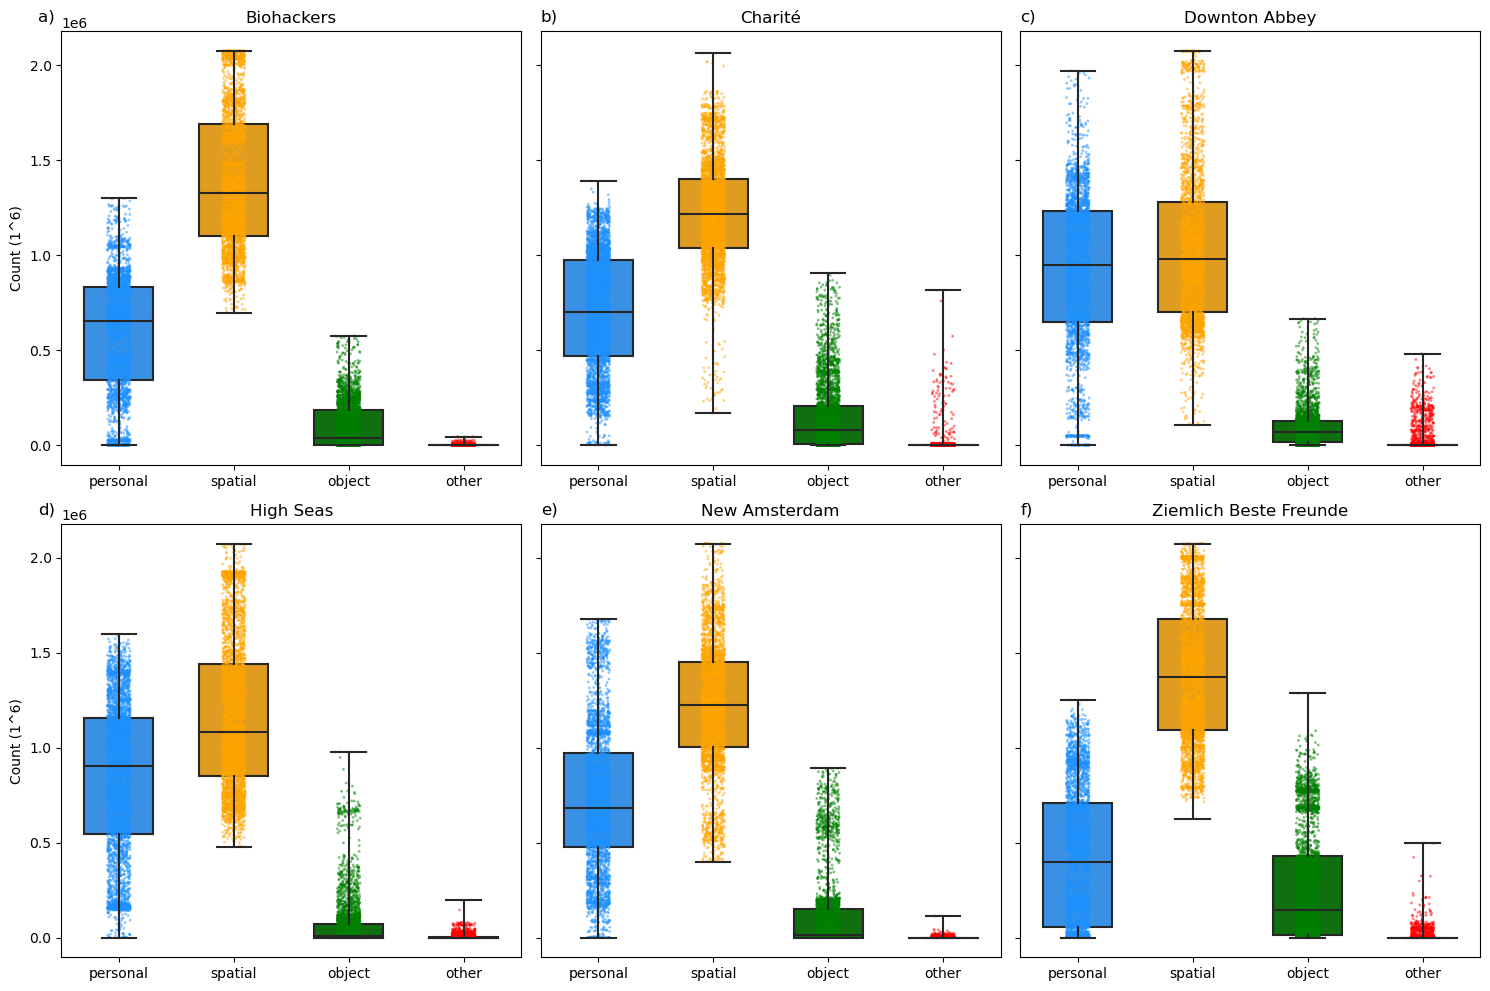

In [10]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Declare Filepaths
frames_path = (r"~\Data\Semantic_01_Segmentation")

# Get the list of frame count CSV files in the specified folder
frame_counts_files = [file for file in os.listdir(frames_path) if file.endswith('_frame_counts.csv')]

# Calculate the number of figures to create
num_figures = len(frame_counts_files)

# Set the number of columns for the subplots
num_cols = 3

# Calculate the number of rows required based on the number of figures and columns
num_rows = (num_figures + num_cols - 1) // num_cols

color_dict = {'personal': 'DodgerBlue',
              'spatial': 'Orange',
              'object': 'green',
              'other': 'red'
              }

# Create the subplots with a single row and multiple columns
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 10), sharey=True)

# Flatten the axes array to make it easier to work with
axes = axes.flatten()

# Iterate through the frame count CSV files and create the swarmplot for each
for i, frame_counts_file in enumerate(frame_counts_files):
    # Read the frame counts CSV file
    frame_counts = pd.read_csv(os.path.join(frames_path, frame_counts_file))

    # Reshape the data using melt
    melted_frame_counts = frame_counts.melt(id_vars='Frame', var_name='Designation', value_name='Count')

    # Create the swarmplot on the current subplot
    sns.boxplot(data=melted_frame_counts, x='Designation', y='Count', ax=axes[i], whis=[0, 100], width=.6, palette=color_dict)
    sns.stripplot(data=melted_frame_counts, x='Designation', y='Count', ax=axes[i], zorder=1, size=2, alpha = 0.5, palette=color_dict)

    # Set the title for the subplot
    axes[i].set_title(f"{frame_counts_file[:-17]}")

    # Set the x-label and y-label for the subplot
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    

# Remove any empty subplots
if num_figures < num_rows * num_cols:
    for j in range(num_figures, num_rows * num_cols):
        fig.delaxes(axes[j])

# Adjust the spacing between subplots
axes[0].set_ylabel('Count (1^6)')
axes[3].set_ylabel('Count (1^6)')

axes[0].set_title(f"Biohackers")
axes[0].text(-0.05, 1.05, "a)", transform=axes[0].transAxes, fontsize=12, va='top')
axes[1].set_title(f"Charité")
axes[1].text(0.00, 1.05, "b)", transform=axes[1].transAxes, fontsize=12, va='top')
axes[2].set_title(f"Downton Abbey")
axes[2].text(0.00, 1.05, "c)", transform=axes[2].transAxes, fontsize=12, va='top')
axes[3].set_title(f"High Seas")
axes[3].text(-0.05, 1.05, "d)", transform=axes[3].transAxes, fontsize=12, va='top')
axes[4].set_title(f"New Amsterdam")
axes[4].text(0.00, 1.05, "e)", transform=axes[4].transAxes, fontsize=12, va='top')
axes[5].set_title(f"Ziemlich Beste Freunde")
axes[5].text(0.00, 1.05, "f)", transform=axes[5].transAxes, fontsize=12, va='top')

fig.tight_layout()

# Show the figure
plt.show()

# # Create the swarmplot
# sns.stripplot(data=melted_frame_counts, x='Designation', y='Count', zorder=1, size=2, alpha = 0.5, dodge=True, jitter=True)
# plt.title(f"Designations Swarmplot - {frame_counts_file[:-17]}")
# plt.xlabel('Designation')
# plt.ylabel('Count')
# plt.show()